In [ ]:
# 01 — Exploratory Data Analysis. The "look before you model" step. Loads the
# feature table (from Snowflake once, then a local parquet cache) and inspects
# it: data coverage per station, the PM2.5 distribution (heavy-tailed), the
# daily/weekly pollution cycles, how strongly past values predict future ones,
# and a preview of the time-based train/val/test split.

In [2]:
# Cell 1 — setup + load (Snowflake once, then local parquet cache)
import sys
from pathlib import Path
ROOT = Path.cwd()
ROOT = ROOT if (ROOT / "common").exists() else ROOT.parent   # works from pipeline/ or pipeline/modeling/
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd, matplotlib.pyplot as plt

CACHE = ROOT / "modeling" / "feat_airquality.parquet"
if CACHE.exists():
    df = pd.read_parquet(CACHE); print("loaded cache:", CACHE)
else:
    from common.snowflake_io import fetch_df
    df = fetch_df("SELECT * FROM AIRQUALITY.ANALYTICS.FEAT_AIRQUALITY")  # adjust schema if your dbt profile differs
    df.columns = df.columns.str.lower()
    df["valid_time"] = pd.to_datetime(df["valid_time"], utc=True)
    CACHE.parent.mkdir(parents=True, exist_ok=True); df.to_parquet(CACHE)
    print("pulled from Snowflake, cached ->", CACHE)

df = df.sort_values(["station_id", "valid_time"]).reset_index(drop=True)
print(df.shape); df.head()

loaded cache: /Users/gurvc/Desktop-Files/forecasting/airquality/pipeline/modeling/feat_airquality.parquet
(6272, 15)


,station_id,valid_time,pm25,pm25_lag_1h,pm25_lag_24h,pm25_lag_48h,pm25_roll_mean_24h,pm25_roll_max_24h,temperature_2m,wind_speed_10m,wind_direction_10m,precipitation,hour_local,day_of_week,was_imputed
0,kelowna,2026-04-01 19:00:00+00:00,4.5,NaN,NaN,NaN,4.500000,4.5,6.0,4.6,141.0,0.0,12,3,False
1,kelowna,2026-04-01 20:00:00+00:00,4.6,4.5,NaN,NaN,4.550000,4.6,6.7,4.7,266.0,0.0,13,3,False
2,kelowna,2026-04-01 21:00:00+00:00,5.1,4.6,NaN,NaN,4.733333,5.1,7.1,3.6,233.0,0.0,14,3,False
3,kelowna,2026-04-01 22:00:00+00:00,4.5,5.1,NaN,NaN,4.675000,5.1,7.9,4.0,270.0,0.0,15,3,False
4,kelowna,2026-04-01 23:00:00+00:00,4.8,4.5,NaN,NaN,4.700000,5.1,8.9,0.5,225.0,0.0,16,3,False


In [3]:
# Cell 2 — coverage, depth, credits/seasonality sanity
print("range:", df.valid_time.min(), "->", df.valid_time.max(),
      "| span days:", (df.valid_time.max() - df.valid_time.min()).days)
print("\nrows per station:\n", df.station_id.value_counts())
print("\nmonths present (climatology depth):\n", df.valid_time.dt.to_period("M").value_counts().sort_index())
print("\nimputed fraction per station:\n", df.groupby("station_id").was_imputed.mean().round(3))

range: 2026-04-01 19:00:00+00:00 -> 2026-06-30 17:00:00+00:00 | span days: 89

rows per station:
 station_id
vancouver        2159
prince_george    2128
kelowna          1985
Name: count, dtype: int64

months present (climatology depth):
 valid_time
2026-04    2072
2026-05    2232
2026-06    1968
Freq: M, Name: count, dtype: int64

imputed fraction per station:
 station_id
kelowna          0.098
prince_george    0.006
vancouver        0.005
Name: was_imputed, dtype: float64


/var/folders/98/379jlrps2_j38h60dstkntzc0000gn/T/ipykernel_4064/2392322592.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  print("\nmonths present (climatology depth):\n", df.valid_time.dt.to_period("M").value_counts().sort_index())


                   mean  50%   max
station_id                        
kelowna        3.479950  3.0  26.0
prince_george  5.745959  4.0  53.7
vancouver      5.020519  4.7  25.6


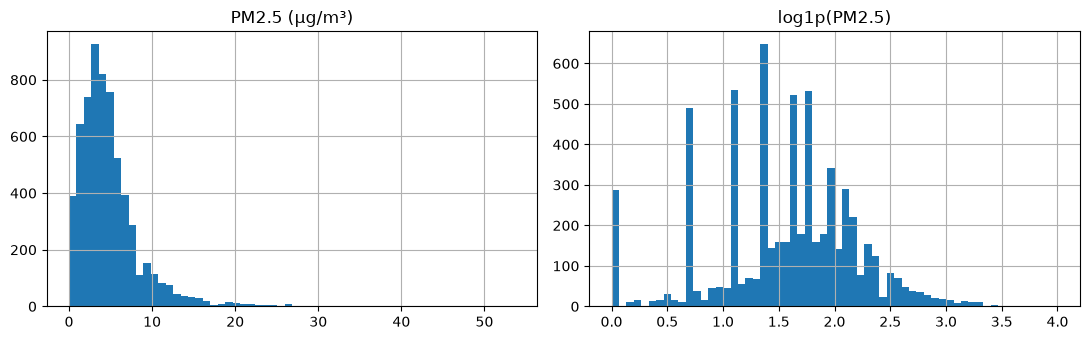

In [4]:
# Cell 3 — target distribution (PM2.5 is heavy-tailed; this decides log-target vs raw)
print(df.groupby("station_id").pm25.describe()[["mean","50%","max"]])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
df.pm25.hist(bins=60, ax=ax[0]); ax[0].set_title("PM2.5 (µg/m³)")
np.log1p(df.pm25).hist(bins=60, ax=ax[1]); ax[1].set_title("log1p(PM2.5)")
plt.tight_layout()

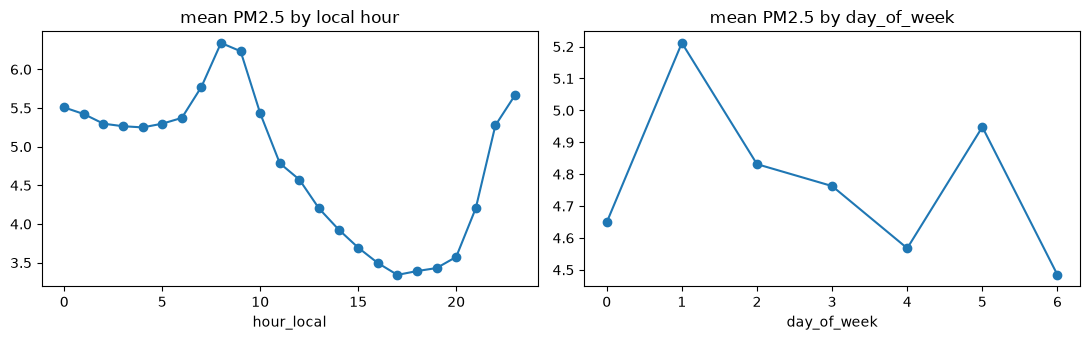

In [5]:
# Cell 4 — seasonality: the diurnal cycle (your local-time feature) + weekly
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
df.groupby("hour_local").pm25.mean().plot(ax=ax[0], marker="o", title="mean PM2.5 by local hour")
df.groupby("day_of_week").pm25.mean().plot(ax=ax[1], marker="o", title="mean PM2.5 by day_of_week")
plt.tight_layout()

Text(0.5, 1.0, 'PM2.5 over time')

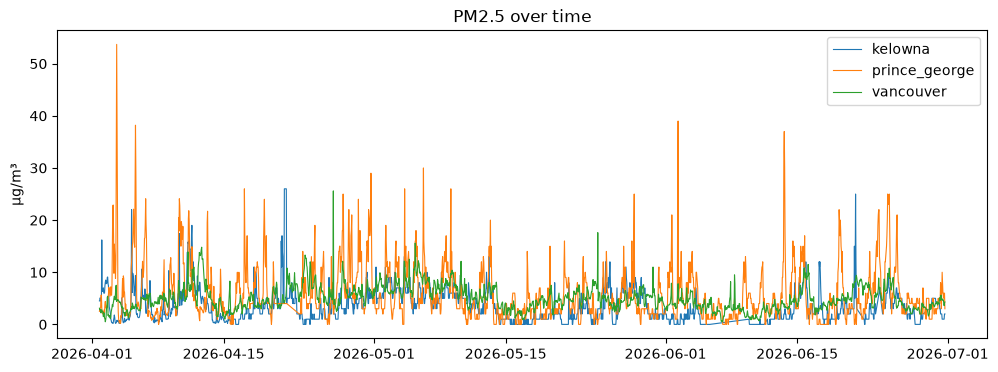

In [6]:
# Cell 5 — eyeball the series per station (spot smoke spikes / sensor dropouts)
fig, ax = plt.subplots(figsize=(12, 4))
for sid, g in df.groupby("station_id"):
    ax.plot(g.valid_time, g.pm25, lw=0.8, label=sid)
ax.legend(); ax.set_ylabel("µg/m³"); ax.set_title("PM2.5 over time")

In [7]:
# Cell 6 — persistence strength: how well do lags predict? (sets the baseline bar)
print(df[["pm25","pm25_lag_1h","pm25_lag_24h","pm25_lag_48h"]].corr()["pm25"].round(3))

pm25            1.000
pm25_lag_1h     0.862
pm25_lag_24h    0.362
pm25_lag_48h    0.255
Name: pm25, dtype: float64


In [8]:
# Cell 7 — build the t+24h target the GAP-AWARE way (previews 2b's #1 silent bug)
H = 24
df["target_pm25"] = df.groupby("station_id").pm25.shift(-H)
ahead = df.groupby("station_id").valid_time.shift(-H) - df.valid_time
df["target_valid"] = ahead == pd.Timedelta(hours=H)   # reject pairs that straddle a dropped gap
print("rows:", len(df), "| usable t+24h examples:", int(df.target_valid.sum()))
print(df[df.target_valid].station_id.value_counts())

rows: 6272 | usable t+24h examples: 6046
station_id
vancouver        2135
prince_george    2080
kelowna          1831
Name: count, dtype: int64


/var/folders/98/379jlrps2_j38h60dstkntzc0000gn/T/ipykernel_4064/2418464883.py:5: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  df["target_valid"] = ahead == pd.Timedelta(hours=H)   # reject pairs that straddle a dropped gap


In [9]:
# Cell 8 — exceedance class balance (decides pos_weight + whether binary is even viable now)
THRESH = 35.4
sub = df[df.target_valid]
exc = sub.target_pm25 > THRESH
print(f"exceedance (>{THRESH}) base rate: {exc.mean():.3%}  ({int(exc.sum())}/{len(sub)})")
print(sub.assign(e=exc).groupby("station_id").e.mean().round(4))

exceedance (>35.4) base rate: 0.083%  (5/6046)
station_id
kelowna          0.0000
prince_george    0.0024
vancouver        0.0000
Name: e, dtype: float64


In [10]:
# Cell 9 — feature → target correlation preview (what the LSTM/XGB will lean on)
feat = ["pm25_lag_1h","pm25_lag_24h","pm25_lag_48h","pm25_roll_mean_24h","pm25_roll_max_24h",
        "temperature_2m","wind_speed_10m","wind_direction_10m","precipitation","hour_local","day_of_week"]
print(sub[feat + ["target_pm25"]].corr()["target_pm25"].drop("target_pm25").sort_values().round(3))

temperature_2m       -0.177
wind_speed_10m       -0.165
hour_local           -0.136
precipitation        -0.053
day_of_week          -0.046
wind_direction_10m    0.013
pm25_lag_48h          0.154
pm25_roll_max_24h     0.225
pm25_roll_mean_24h    0.240
pm25_lag_24h          0.250
pm25_lag_1h           0.346
Name: target_pm25, dtype: float64


In [11]:
# Cell 10 — time-aware split preview (70/15/15 BY TIME — sizes your future test set)
t = df.valid_time; q70, q85 = t.quantile(.70), t.quantile(.85)
for name, m in [("train", t<q70), ("val",(t>=q70)&(t<q85)), ("test", t>=q85)]:
    s = df[m & df.target_valid]
    print(f"{name:6} n={len(s):5d}  exceedance={(s.target_pm25>35.4).mean():.2%}  ({s.valid_time.min()} → {s.valid_time.max()})")

train  n= 4364  exceedance=0.09%  (2026-04-01 19:00:00+00:00 → 2026-06-02 03:00:00+00:00)
val    n=  886  exceedance=0.11%  (2026-06-02 04:00:00+00:00 → 2026-06-16 23:00:00+00:00)
test   n=  796  exceedance=0.00%  (2026-06-17 00:00:00+00:00 → 2026-06-29 17:00:00+00:00)
